## Modelo lineal
datos 1,2,3
variable respuesta 3,5,7

In [8]:
import numpy as np
import seaborn as sns
import matplotlib

# Datos
x = np.array([1, 2, 3])
y = np.array([3, 5, 7])

# Matriz de diseño (grado 1)
X = np.column_stack((np.ones(len(x)), x))

print("Matriz de diseño X:")
print(X)

# Pseudoinversa de X
X_pinv = np.linalg.pinv(X)

print("\nPseudoinversa de X:")
print(X_pinv)

# Parámetros del modelo (beta)
beta = X_pinv @ y

print("\nParámetros del modelo:")
print("beta_0 (intercepto):", beta[0])
print("beta_1 (pendiente):", beta[1])

Matriz de diseño X:
[[1. 1.]
 [1. 2.]
 [1. 3.]]

Pseudoinversa de X:
[[ 1.33333333e+00  3.33333333e-01 -6.66666667e-01]
 [-5.00000000e-01 -3.02420752e-17  5.00000000e-01]]

Parámetros del modelo:
beta_0 (intercepto): 1.0000000000000013
beta_1 (pendiente): 1.9999999999999996


Matriz de diseño X:
[[1. 1.]
 [1. 2.]
 [1. 3.]]

Pseudoinversa de X:
[[ 1.33333333e+00  3.33333333e-01 -6.66666667e-01]
 [-5.00000000e-01 -3.02420752e-17  5.00000000e-01]]

Parámetros del modelo:
beta_0 (intercepto): 1.0000000000000013
beta_1 (pendiente): 1.9999999999999996

Evaluación con phi^T:
x = 1 -> phi^T = [1 1], y_pred = 3.000000000000001
x = 2 -> phi^T = [1 2], y_pred = 5.0
x = 3 -> phi^T = [1 3], y_pred = 7.0


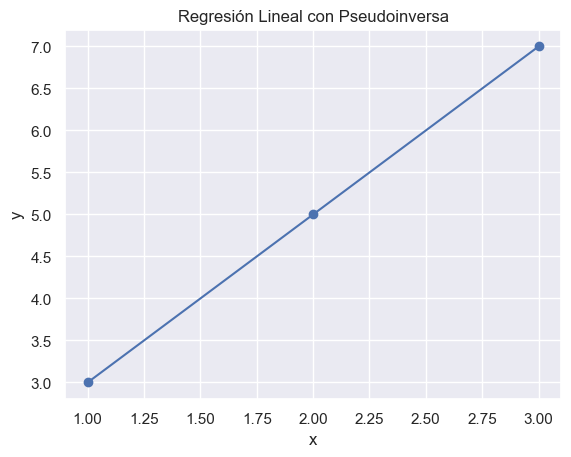

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

x = np.array([1, 2, 3])
y = np.array([3, 5, 7])

X = np.column_stack((np.ones(len(x)), x))

print("Matriz de diseño X:")
print(X)

X_pinv = np.linalg.pinv(X)

print("\nPseudoinversa de X:")
print(X_pinv)

beta = X_pinv @ y

print("\nParámetros del modelo:")
print("beta_0 (intercepto):", beta[0])
print("beta_1 (pendiente):", beta[1])


print("\nEvaluación con phi^T:")

for xi in x:
    phi_T = np.array([1, xi])   # phi^T(x)
    y_pred = phi_T @ beta
    print(f"x = {xi} -> phi^T = {phi_T}, y_pred = {y_pred}")

sns.set()


x_line = np.linspace(1, 3, 100)
y_line = beta[0] + beta[1] * x_line


plt.scatter(x, y)
plt.plot(x_line, y_line)

plt.title("Regresión Lineal con Pseudoinversa")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

In [ ]:
from drawdata import ScatterWidget
widget = ScatterWidget()
widget

In [57]:
data = widget.data_as_pandas
data

,x,y,color,label,batch
0,229.683081,202.543591,#1f77b4,a,0
1,239.567849,222.033215,#1f77b4,a,0
2,221.708946,224.988969,#1f77b4,a,0
3,238.112924,196.023822,#1f77b4,a,0
4,254.984929,203.341035,#1f77b4,a,0
5,243.979435,217.938380,#1f77b4,a,0
6,248.549123,196.814997,#1f77b4,a,0
7,274.199233,200.216564,#1f77b4,a,0
8,276.161739,218.689997,#1f77b4,a,0
9,280.954482,240.420282,#1f77b4,a,0


In [58]:
x = data.x.values.reshape(-1, 1)
y = data.y.values.reshape(-1, 1)
#x, y

In [59]:

phi = np.hstack([np.ones((x.shape[0], 1)), x])
phi

array([[  1.        , 229.68308134],
       [  1.        , 239.56784909],
       [  1.        , 221.70894576],
       [  1.        , 238.11292356],
       [  1.        , 254.98492898],
       [  1.        , 243.9794347 ],
       [  1.        , 248.54912277],
       [  1.        , 274.1992332 ],
       [  1.        , 276.16173945],
       [  1.        , 280.9544816 ],
       [  1.        , 300.49825214],
       [  1.        , 298.76878047],
       [  1.        , 332.44083875],
       [  1.        , 321.43011488],
       [  1.        , 325.27564812],
       [  1.        , 367.43024057],
       [  1.        , 382.99084006],
       [  1.        , 391.3042788 ],
       [  1.        , 368.9178306 ],
       [  1.        , 381.13169763],
       [  1.        , 397.89023665],
       [  1.        , 389.96832403],
       [  1.        , 405.31114377],
       [  1.        , 417.45982631],
       [  1.        , 400.11033957],
       [  1.        , 431.68514585],
       [  1.        , 408.93697392]])

In [60]:
pseudo_inv = np.linalg.inv(phi.T @ phi) @ phi.T

In [61]:
params = pseudo_inv @ y
np.round(params, 2)

array([[127.81],
       [  0.34]])

<Axes: xlabel='x', ylabel='y'>

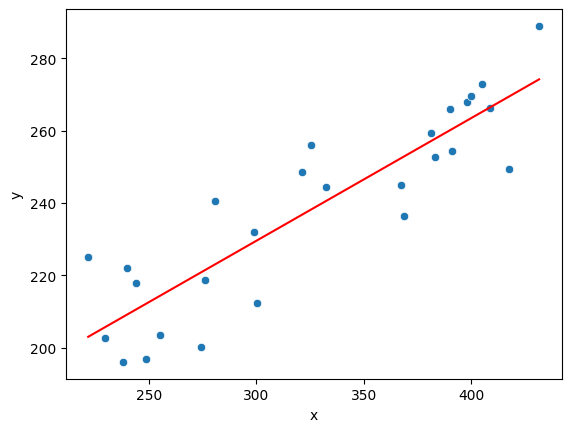

In [62]:
sns.scatterplot(x='x',y='y',data=data)
x_linspace = np.linspace(x.min(), x.max(), 100)
y_pred = params[0] + params[1] * x_linspace 
sns.lineplot(x = x_linspace, y= y_pred, color = "red")

In [70]:
x = x.reshape(-1)

In [71]:
phi = np.array([np.ones(len(x)), x]).T
phi


array([[  1.        , 229.68308134],
       [  1.        , 239.56784909],
       [  1.        , 221.70894576],
       [  1.        , 238.11292356],
       [  1.        , 254.98492898],
       [  1.        , 243.9794347 ],
       [  1.        , 248.54912277],
       [  1.        , 274.1992332 ],
       [  1.        , 276.16173945],
       [  1.        , 280.9544816 ],
       [  1.        , 300.49825214],
       [  1.        , 298.76878047],
       [  1.        , 332.44083875],
       [  1.        , 321.43011488],
       [  1.        , 325.27564812],
       [  1.        , 367.43024057],
       [  1.        , 382.99084006],
       [  1.        , 391.3042788 ],
       [  1.        , 368.9178306 ],
       [  1.        , 381.13169763],
       [  1.        , 397.89023665],
       [  1.        , 389.96832403],
       [  1.        , 405.31114377],
       [  1.        , 417.45982631],
       [  1.        , 400.11033957],
       [  1.        , 431.68514585],
       [  1.        , 408.93697392]])

In [72]:
w = np.array(([0], [0]))
lr = 0.1
w, lr

(array([[0],
        [0]]),
 0.1)

In [73]:

epochs = 100
for epoch in range(epochs):
    ols = 0.5 * (y - phi @ w) ** 2
    grad = -phi.T @ (y - phi @ w)
    w = w + lr * grad
w

/var/folders/r4/mgkrh5bj69q4qmwxnclqj6zm0000gn/T/ipykernel_3252/2113690964.py:3: RuntimeWarning: overflow encountered in square
  ols = 0.5 * (y - phi @ w) ** 2
/var/folders/r4/mgkrh5bj69q4qmwxnclqj6zm0000gn/T/ipykernel_3252/2113690964.py:3: RuntimeWarning: overflow encountered in matmul
  ols = 0.5 * (y - phi @ w) ** 2
/var/folders/r4/mgkrh5bj69q4qmwxnclqj6zm0000gn/T/ipykernel_3252/2113690964.py:4: RuntimeWarning: overflow encountered in matmul
  grad = -phi.T @ (y - phi @ w)


array([[-inf],
       [-inf]])